In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/shivrajrakte/ecommerce-furniture-dataset/ecommerce_furniture_dataset_2024.csv


In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/shivrajrakte/ecommerce-furniture-dataset/ecommerce_furniture_dataset_2024.csv")

df.head()


,productTitle,originalPrice,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,NaN,$46.79,600,Free shipping
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,NaN,$169.72,0,Free shipping
2,Desser For Bedroom With 7 Fabric Drawers Organ...,$78.4,$39.46,7,Free shipping
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",NaN,$111.99,0,Free shipping
4,Small Unit Simple Computer Desk Household Wood...,$48.82,$21.37,1,Free shipping


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n")
print(df.isnull().sum())


Dataset Shape: (2000, 5)

Columns:
 Index(['productTitle', 'originalPrice', 'price', 'sold', 'tagText'], dtype='object')

Missing Values:

productTitle        0
originalPrice    1513
price               0
sold                0
tagText             3
dtype: int64


In [5]:
if 'originalPrice' in df.columns:
    df.drop('originalPrice', axis=1, inplace=True)


In [6]:
# Convert price column to string first
df['price'] = df['price'].astype(str)

# Remove everything except numbers and dot
df['price'] = df['price'].str.replace(r'[^0-9.]', '', regex=True)

# Convert to float
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Check result
df['price'].head()


0     46.79
1    169.72
2     39.46
3    111.99
4     21.37
Name: price, dtype: float64

In [7]:
print(df['price'].dtype)


float64


In [8]:
# Convert to string first
df['price'] = df['price'].astype(str)

# Remove everything except numbers and dot
df['price'] = df['price'].str.replace(r'[^0-9.]', '', regex=True)

# Convert to numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Check how many missing values
print("Missing prices:", df['price'].isnull().sum())

# Fill missing values with median
df['price'] = df['price'].fillna(df['price'].median())

# Confirm no missing values
print("Missing after filling:", df['price'].isnull().sum())


Missing prices: 0
Missing after filling: 0


In [9]:
df['tagText'] = df['tagText'].fillna('others')

df['tagText'] = df['tagText'].apply(
    lambda x: 'Free shipping' if 'Free' in str(x) else 'Paid shipping'
)


In [10]:
df.head()


,productTitle,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,46.79,600,Free shipping
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,169.72,0,Free shipping
2,Desser For Bedroom With 7 Fabric Drawers Organ...,39.46,7,Free shipping
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",111.99,0,Free shipping
4,Small Unit Simple Computer Desk Household Wood...,21.37,1,Free shipping


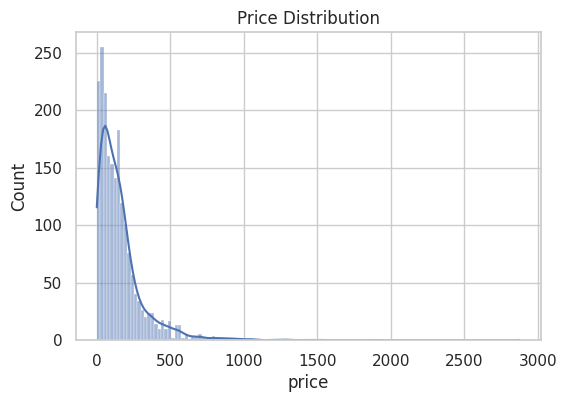

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()


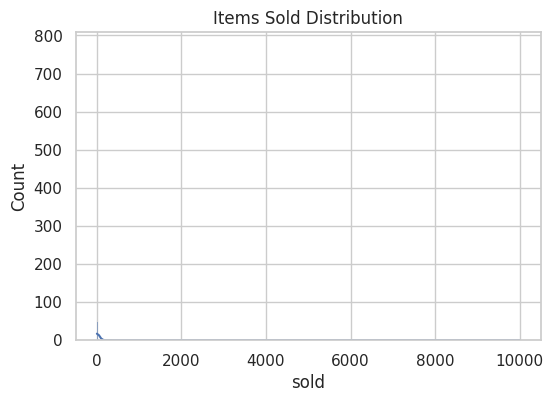

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df['sold'], kde=True)
plt.title("Items Sold Distribution")
plt.show()


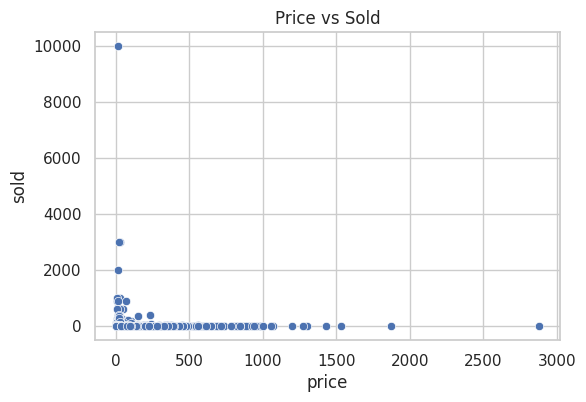

In [13]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='price', y='sold', data=df)
plt.title("Price vs Sold")
plt.show()


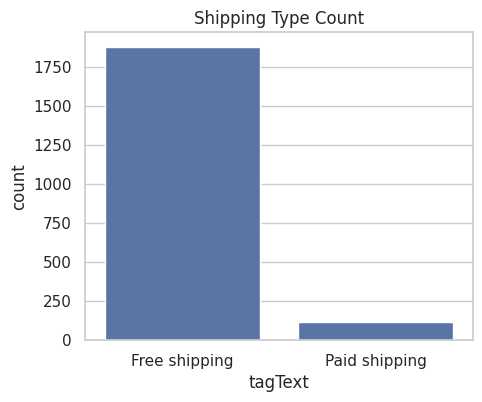

In [14]:
plt.figure(figsize=(5,4))
sns.countplot(x='tagText', data=df)
plt.title("Shipping Type Count")
plt.show()


In [15]:
print("Average Sales by Shipping Type:")
print(df.groupby('tagText')['sold'].mean())


Average Sales by Shipping Type:
tagText
Free shipping    23.644681
Paid shipping    21.125000
Name: sold, dtype: float64


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['shipping_encoded'] = le.fit_transform(df['tagText'])


In [17]:
from sklearn.model_selection import train_test_split

X = df[['price', 'shipping_encoded']]
y = df['sold']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Mean Squared Error: 5406.871903482724
R2 Score: 0.013977716110169291


In [20]:
print("""
Conclusion:
Lower-priced furniture items generally sell more.
Free shipping products tend to have higher sales.
Price and shipping type influence product performance.
""")



Conclusion:
Lower-priced furniture items generally sell more.
Free shipping products tend to have higher sales.
Price and shipping type influence product performance.

